# Pt sample – Quick transport analysis

This notebook contains quick analysis tools for:

1. **V vs T at fixed current**
2. **V–I curves**

The data files are those generated by the Python measurement suite

In [ ]:
# Common setup: imports, plotting style

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from tkinter import Tk, filedialog
from pathlib import Path

# Plot style (adjust as you like)
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["font.size"] = 12
mpl.rcParams["axes.spines.top"] = True
mpl.rcParams["axes.spines.right"] = True

In [ ]:
# Helper functions

def select_file_dialog(title="Select data file"):
    """
    Open an OS file dialog and return the selected file path (as a Path object).
    """
    root = Tk()
    root.withdraw()
    file_path = filedialog.askopenfilename(title=title)
    root.destroy()
    return Path(file_path) if file_path else None

def make_figure_dir(data_file: Path) -> Path:
    """
    Create (if needed) and return a 'figures' subfolder next to the selected data file.
    """
    fig_dir = data_file.parent / "figures"
    fig_dir.mkdir(exist_ok=True)
    return fig_dir

## 1. V vs T analysis (fixed current)

This section:

- Loads a `V_vs_T` file generated by the Python suite  
- Computes \( R(T) = V/I \)  
- Saves plots in a `figures/` folder next to the data file

Selected file: C:\Users\msuarez\OneDrive - Asociacion Cic Nanogune\Python\data\Manuel\Pt\001_V_vs_T_10-300K.txt
Loaded 1716 points.
Applied current: I = 1.000e-05 A
Figures will be saved in: C:\Users\msuarez\OneDrive - Asociacion Cic Nanogune\Python\data\Manuel\Pt\figures


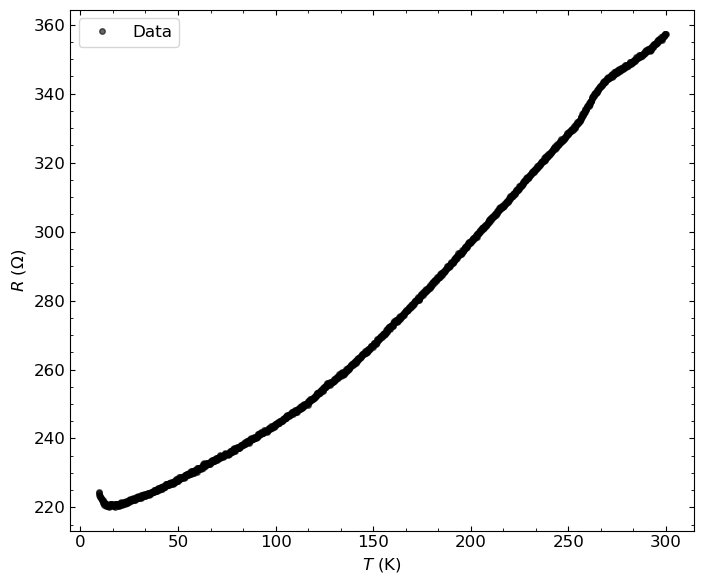

In [20]:
# 1. V vs T analysis (fixed current)

# -------- Data reading --------
data_file = select_file_dialog("Select V_vs_T data file")
if data_file is None:
    raise RuntimeError("No file selected.")

print("Selected file:", data_file)

# The file has commented header lines starting with '#'
df = pd.read_csv(data_file, sep=r"\s+", comment="#", engine="python")

time_s = df["time_s"].values
T = df["T[K]"].values
V = df["V[V]"].values
I = df["I[A]"].iloc[0]   # constant current

print(f"Loaded {len(df)} points.")
print(f"Applied current: I = {I:.3e} A")

# -------- Data analysis --------

R = V / I

# -------- Plot --------

fig2, ax2 = plt.subplots(figsize=(7.2, 6))

ax2.plot(T, R, "o", color="black", alpha=0.6, markersize=4, label="Data")

ax2.set_xlabel(r"$T$ (K)")
ax2.set_ylabel(r"$R$ (Ω)")

ax2.minorticks_on()
ax2.xaxis.set_minor_locator(AutoMinorLocator(3))
ax2.yaxis.set_minor_locator(AutoMinorLocator(4))
ax2.tick_params(axis="both", which="both", direction="in", top=True, right=True)

ax2.legend()
fig2.tight_layout()

# -------- Plot saving --------

FIG_DIR = make_figure_dir(data_file)
print("Figures will be saved in:", FIG_DIR)
fig2.savefig(FIG_DIR / "R_vs_T.png", dpi=300, transparent=True)
mpl.rcParams["svg.fonttype"] = "none"
#fig2.savefig(FIG_DIR / "R_vs_T.svg", bbox_inches="tight")

plt.show()

## 2. V–I analysis

This section:

- Loads a `V_vs_I` file generated by the Python suite  
- Performs a linear fit to extract resistance
- Saves plots in a `figures/` folder next to the data file

Selected file: C:\Users\msuarez\OneDrive - Asociacion Cic Nanogune\Python\data\Manuel\Pt\001_V_vs_I_300K.txt
Resistance from I–V fit: R = 3.488e+02 Ω
Offset voltage: 1.858e-04 V
Figures will be saved in: C:\Users\msuarez\OneDrive - Asociacion Cic Nanogune\Python\data\Manuel\Pt\figures


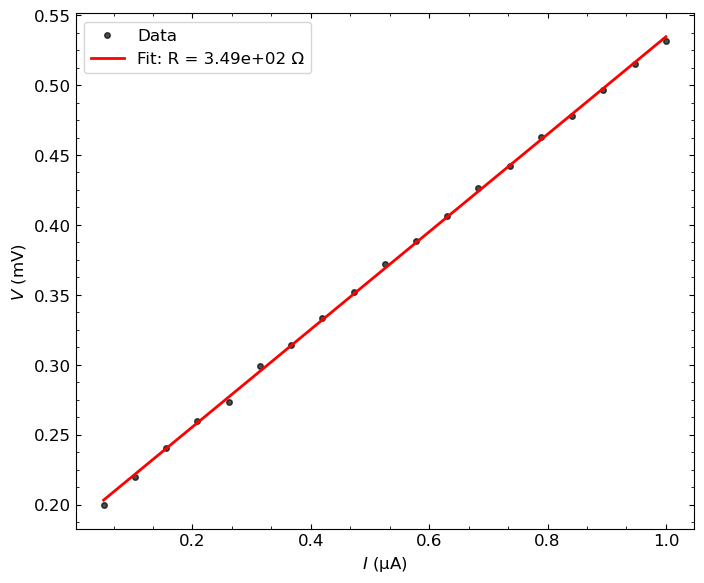

In [19]:
# 2. V–I analysis

# -------- Data reading --------
data_file_iv = select_file_dialog("Select I–V data file")
if data_file_iv is None:
    raise RuntimeError("No file selected.")

print("Selected file:", data_file_iv)

# The file has commented header lines starting with '#'
df_iv = pd.read_csv(data_file_iv, sep=r"\s+", comment="#", engine="python")

I = df_iv["I[A]"].values
V = df_iv["V[V]"].values

# -------- Data analysis --------

R_fit_iv, offset_fit = np.polyfit(I, V, 1)
print(f"Resistance from I–V fit: R = {R_fit_iv:.3e} Ω")
print(f"Offset voltage: {offset_fit:.3e} V")

def V_fit(I_in):
    return R_fit_iv * I_in + offset_fit

# -------- Plot --------
fig_iv, ax_iv = plt.subplots(figsize=(7.2, 6))

ax_iv.plot(I * 1e6, V * 1e3, "o", color="black", alpha=0.7, markersize=4,
           label="Data")
ax_iv.plot(I * 1e6, V_fit(I) * 1e3, "-", color="red", linewidth=2,
           label=f"Fit: R = {R_fit_iv:.2e} Ω")

ax_iv.set_xlabel(r"$I$ (µA)")
ax_iv.set_ylabel(r"$V$ (mV)")

ax_iv.minorticks_on()
ax_iv.xaxis.set_minor_locator(AutoMinorLocator(3))
ax_iv.yaxis.set_minor_locator(AutoMinorLocator(4))
ax_iv.tick_params(axis="both", which="both", direction="in", top=True, right=True)

ax_iv.legend()
fig_iv.tight_layout()

# -------- Plot saving --------

FIG_DIR_IV = make_figure_dir(data_file_iv)
print("Figures will be saved in:", FIG_DIR_IV)
fig_iv.savefig(FIG_DIR_IV / "V_vs_I.png", dpi=300, transparent=True)
mpl.rcParams["svg.fonttype"] = "none"
#fig_iv.savefig(FIG_DIR_IV / "V_vs_I.svg", bbox_inches="tight")

plt.show()